In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    
    for filename in filenames:
        
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mehulgoyal1729/s-sem1-products/S_Sem_products_normed_k100
/kaggle/input/datasets/mehulgoyal1729/s-products-normed-k100/S_products_normed_k100
/kaggle/input/datasets/mehulgoyal1729/ogbn-products-metadataokayy/Products_ogbn_edge_index
/kaggle/input/datasets/mehulgoyal1729/ogbn-products-metadataokayy/Products_ogbn_labels_tensor
/kaggle/input/datasets/mehulgoyal1729/ogbn-products-metadataokayy/Products_ogbn_valid_index
/kaggle/input/datasets/mehulgoyal1729/ogbn-products-metadataokayy/Products_ogbn_node_features
/kaggle/input/datasets/mehulgoyal1729/ogbn-products-metadataokayy/Products_ogbn_train_index
/kaggle/input/datasets/mehulgoyal1729/ogbn-products-metadataokayy/Products_ogbn_test_index


In [2]:
!pip install ogb
!pip install torch_geometric

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.5 MB/s eta 0:00:00a 0:00:01


### Importing the libraries :

In [3]:

import torch
import numpy as np
from torch_geometric.datasets import Planetoid
from torch_geometric.utils import to_torch_csr_tensor   

import torch
from ogb.nodeproppred import NodePropPredDataset 


import wandb 
from sklearn.linear_model import LogisticRegression

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### Importing OGBN Products Dataset :

In [4]:

original_torch_load = torch.load

def patched_torch_load(*args, **kwargs):
    kwargs["weights_only"] = False
    return original_torch_load(*args, **kwargs)

torch.load = patched_torch_load

In [5]:
dataset = NodePropPredDataset(name='ogbn-products')

graph, labels = dataset[0]

graph

This will download 1.38GB. Will you proceed? (y/N)
 y


Downloaded 1.38 GB: 100%|██████████| 1414/1414 [01:12<00:00, 19.52it/s]


Extracting dataset/products.zip
Loading necessary files...
This might take a while.
Processing graphs...


100%|██████████| 1/1 [00:01<00:00,  1.09s/it]


Saving...


{'edge_index': array([[      0,  152857,       0, ..., 2449028,   53324, 2449028],
        [ 152857,       0,   32104, ...,  162836, 2449028,   53324]]),
 'edge_feat': None,
 'node_feat': array([[ 0.03193326, -0.1958605 ,  0.0519961 , ...,  0.07669606,
         -0.3929545 , -0.06478424],
        [-0.02405794,  0.63032097,  1.0605699 , ..., -1.6874819 ,
          3.5866776 ,  0.818219  ],
        [ 0.33269015, -0.5585958 , -0.28860757, ..., -0.37157044,
          0.2520575 ,  0.04153213],
        ...,
        [ 0.10660695,  0.2654852 , -0.00567423, ...,  1.0867023 ,
          0.07590195, -1.1736895 ],
        [ 0.24968362, -0.25740346,  0.41230008, ...,  1.5465808 ,
          1.0309792 , -0.29657176],
        [ 0.7175324 , -0.23930131,  0.04430327, ..., -1.0132493 ,
         -0.41407427, -0.08227058]], dtype=float32),
 'num_nodes': 2449029}

In [6]:

edge_index = torch.tensor(graph['edge_index'], dtype=torch.long)
node_features = torch.tensor(graph['node_feat'], dtype=torch.float)
labels_tensor = torch.tensor(labels, dtype=torch.long).squeeze()



num_nodes = graph['num_nodes']
num_classes = dataset.num_classes

print(f"Nodes: {num_nodes}, Edges: {edge_index.shape[1]}, Classes: {num_classes}")

print(F"Node_features_dim:{node_features.shape}")

Nodes: 2449029, Edges: 123718280, Classes: 47
Node_features_dim:torch.Size([2449029, 100])


In [7]:
# torch.save(edge_index, "Products_ogbn_edge_index")
# torch.save(node_features, "Products_ogbn_node_features")
# torch.save(labels_tensor, "Products_ogbn_labels_tensor")



In [8]:
split_idx = dataset.get_idx_split()

train_idx = split_idx['train']
valid_idx = split_idx['valid']
test_idx = split_idx['test']

# torch.save(train_idx, "Products_ogbn_train_index")
# torch.save(valid_idx, "Products_ogbn_valid_index")
# torch.save(test_idx, "Products_ogbn_test_index")


In [9]:
# import json
# import os

# dataset_metadata = {
#     "title": "ogbn-products-metadataokayy",
#     "id": "mehulgoyal1729/ogbn-products-metadataokayy",
#     "licenses": [{"name": "CC0-1.0"}]
# }

# with open("/kaggle/working/dataset-metadata.json", "w") as f:
#     json.dump(dataset_metadata, f)

In [10]:
# !kaggle datasets files mehulgoyal1729/ogbn-products-metadataokayy

In [11]:
# n is the total number of nodes (num_nodes = 2,449,029)
n = num_nodes 

# 1. Initialize the boolean array (all False by default)
is_labeled = torch.zeros(n, dtype=torch.bool, device=device)

# 2. Apply True ONLY to the official training nodes
is_labeled[train_idx] = True

# 3. The masked nodes are simply the exact opposite of the labeled nodes
# (This perfectly covers both valid_idx and test_idx)
is_masked = ~is_labeled 

# 4. Create the masked labels tensor for your random walks and supervised gradients
labels_masked = labels_tensor.clone().to(device)
labels_masked[is_masked] = -1

# --- Sanity Check to confirm counts ---
print(f"Total Nodes: {n}")
print(f"Labeled (Train): {is_labeled.sum().item()}")
print(f"Masked (Valid + Test): {is_masked.sum().item()}")

Total Nodes: 2449029
Labeled (Train): 196615
Masked (Valid + Test): 2252414


In [12]:
print(f"Train_idx_count:{len(train_idx)}")
print(f"valid_idx_count:{len(valid_idx)}")
print(f"test_idx_count:{len(test_idx)}")

Train_idx_count:196615
valid_idx_count:39323
test_idx_count:2213091


In [13]:
# Assuming n = num_nodes and labels_tensor is your original ground-truth tensor

# 1. Initialize an array of -1 (meaning all nodes are unlabelled/masked by default)
labels_masked = torch.full((n,), -1, dtype=torch.long, device=device)

# 2. Inject the true labels ONLY for the training nodes
# This safely guarantees zero data leakage from valid/test splits
labels_masked[train_idx] = labels_tensor[train_idx].to(device)

# 3. Create the boolean mask needed for the random walk logic
# This will evaluate to True for all nodes in valid_idx and test_idx
is_masked = (labels_masked == -1)

# Verify the shapes and counts
print(f"Masked Labels: {labels_masked.shape}")
print(f"Labeled nodes (Train): {(labels_masked != -1).sum().item()}")
print(f"Unlabeled nodes (Valid + Test): {is_masked.sum().item()}")

Masked Labels: torch.Size([2449029])
Labeled nodes (Train): 196615
Unlabeled nodes (Valid + Test): 2252414


In [14]:
print(f"Original Feature Matrix Shape: {node_features.shape}")

Original Feature Matrix Shape: torch.Size([2449029, 100])


## 2. Build sparse adjacency + degree vector


In [15]:
n = num_nodes
m = edge_index.shape[1] // 2  # undirected → each edge counted twice

edge_index

tensor([[      0,  152857,       0,  ..., 2449028,   53324, 2449028],
        [ 152857,       0,   32104,  ...,  162836, 2449028,   53324]])

In [18]:
# self edges removal mask :
mask = edge_index[0] != edge_index[1]
edge_index_clean = edge_index[:, mask]



# A_sparse = to_torch_csr_tensor(edge_index, size=(n, n)).to(device)
# in csr representation, we will just recird the non zero values in the adjacecny matrix and their positions in it.

# total number of such will the ttoal number of edges 

#      Fallback: manual COO → CSR
vals = torch.ones(edge_index.shape[1], dtype=torch.float32)
A_sparse = torch.sparse_coo_tensor(edge_index, vals, (n, n)).to_sparse_csr().to(device)
deg = torch.zeros(n, dtype=torch.float32, device=device)
deg.scatter_add_(0, edge_index[0].to(device), torch.ones(edge_index.shape[1], device=device))
d = deg.unsqueeze(1)   # [n, 1]

labels = labels_tensor# [n]
print(f'A_sparse: {A_sparse.shape}, nnz={A_sparse._nnz()}, d: {d.shape}')

/tmp/ipykernel_57/1931414304.py:14: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:49.)
  A_sparse = torch.sparse_coo_tensor(edge_index, vals, (n, n)).to_sparse_csr().to(device)


A_sparse: torch.Size([2449029, 2449029]), nnz=123718152, d: torch.Size([2449029, 1])


## 3. Initialise embeddings (No need to run this if testing ready made embeddings):


- We will match the embeddings length with that of the Arxiv used in the paper.

#### Other Hyperparams for Arxiv:

- lr = 0.05
- Iterations  = 200
- 


In [ ]:
import torch

S = torch.randn(n, 100, device=device)

# Move to CPU RAM before calculating QR
S_cpu = S.cpu()
del S 
torch.cuda.empty_cache()

Q_cpu, _ = torch.linalg.qr(S_cpu, mode='reduced')

# Move the result back to GPU VRAM
S = Q_cpu.to(device)
del Q_cpu

In [20]:
# K = 100   # embedding dimension

# S = torch.randn(n, K, device=device)
# Q, _ = torch.linalg.qr(S)
# S = Q  # [n, K] orthonormal
# print('S:', S.shape)

In [19]:
# def build_padded_adj(edge_index: torch.Tensor, n: int, device):
#     """
#     Build a padded neighbour matrix [n, max_degree] (int64).
#     Padding value = node itself (self-loop) so walks don't crash on padding.
#     Also returns the true degree for each node.
#     """
#     src, dst = edge_index[0], edge_index[1]
#     deg_cpu = torch.zeros(n, dtype=torch.long)
#     deg_cpu.scatter_add_(0, src, torch.ones_like(src))
#     max_deg = int(deg_cpu.max().item())
#     print(max_deg) # this is the max dim[1] for the padded adj


    
#     # Sort edges by src to group neighbours together
#     order = torch.argsort(src)
#     src_s, dst_s = src[order], dst[order]

#     # Position of each edge within its source's neighbour list
#     cum = torch.zeros(n + 1, dtype=torch.long)
#     cum[1:] = torch.cumsum(deg_cpu, 0)
#     local_pos = torch.arange(src_s.shape[0]) - cum[src_s]

#     # Initialise with self-loop padding
#     padded = torch.arange(n).unsqueeze(1).expand(n, max_deg).clone()  # [n, max_deg]
#     padded[src_s, local_pos] = dst_s

#     return padded.to(device), deg_cpu.to(device), max_deg


# padded_adj, deg_vec, max_deg = build_padded_adj(edge_index, n, device)
# print(f'Padded adj: {padded_adj.shape}, max_degree={max_deg}')


# csr without paddng:

def build_csr_graph(edge_index: torch.Tensor, n: int, device):
    """
    Converts the edge list into 1D CSR format arrays.
    Memory footprint: O(|V| + |E|). No padding, no capping.
    """
    src, dst = edge_index[0], edge_index[1]
    
    # 1. Sort edges by source node
    order = torch.argsort(src)
    src_s, dst_s = src[order], dst[order]
    
    # 2. Get true degree of every node
    deg = torch.bincount(src_s, minlength=n).to(device)
    
    # 3. Build the Row Pointers (cumulative sum of degrees)
    # This tells us exactly where in the dst_s array a node's neighbors start
    row_ptr = torch.zeros(n + 1, dtype=torch.long, device=device)
    row_ptr[1:] = torch.cumsum(deg, dim=0)
    
    # The flattened array of all neighbors
    col_idx = dst_s.to(device)
    
    return row_ptr, col_idx, deg

# This will take seconds and use almost no RAM.
row_ptr, col_idx, deg_vec = build_csr_graph(edge_index_clean, n, device)
print(f"Row Pointers: {row_ptr.shape}, Flattened Edges: {col_idx.shape}")

Row Pointers: torch.Size([2449030]), Flattened Edges: torch.Size([123718024])


### Batched CSR adajcency matrix based Random Walk  :

In [20]:
# def batched_biased_random_walk(
#     padded_adj,   # [n, max_deg] int64
#     deg_vec,      # [n] int64
#     labels_masked,# [n] int64  (-1 = unlabelled)
#     is_masked,    # [n] bool
#     r=20, L=4, Lp=1,
#     beta=1.0,     # bias multiplier for labelled neighbours
#     device='cpu'):
 
#     unlab_ids = torch.where(is_masked)[0]            # [n_unlab]
#     n_unlab   = unlab_ids.shape[0]

#     # Storage: [n_unlab, r, Lp] – fill with -1 ("not found")
#     walk_neigh = torch.full((n_unlab, r, Lp), -1, dtype=torch.long, device=device)
#     labeled_count = torch.zeros(n_unlab, r, dtype=torch.long, device=device)

#     # Current position for each walker: [n_unlab, r]
#     current = unlab_ids.unsqueeze(1).expand(n_unlab, r).clone()  # [n_unlab, r]

#     for step in range(L):
#         # Gather neighbours for all current positions: [n_unlab, r, max_deg]
#         neigh = padded_adj[current]                              # [n_unlab, r, max_deg]
#         deg_here = deg_vec[current].clamp(min=1)                 # [n_unlab, r]

#         # Label status of each neighbour: True if labelled
#         neigh_labels = labels_masked[neigh]                      # [n_unlab, r, max_deg]
#         is_lab_neigh = (neigh_labels != -1)                      # [n_unlab, r, max_deg] bool

#         # Build sampling weights – uniform within valid degree, biased for labelled
#         # Mask out padding slots (index >= true degree)
#         slot_idx = torch.arange(padded_adj.shape[1], device=device)   # [max_deg]
#         valid_mask = slot_idx.unsqueeze(0).unsqueeze(0) < deg_here.unsqueeze(2)  # [n_unlab, r, max_deg]

#         weights = torch.where(valid_mask, torch.ones_like(neigh, dtype=torch.float32), torch.zeros_like(neigh, dtype=torch.float32))
#         weights = torch.where(is_lab_neigh & valid_mask, weights * beta, weights)
#         weights = weights + 1e-12   # avoid zero rows

#         # Sample one neighbour per walker: [n_unlab, r]
#         flat_w = weights.view(n_unlab * r, -1)                        # [n_unlab*r, max_deg]
#         chosen_slot = torch.multinomial(flat_w, num_samples=1).squeeze(1)  # [n_unlab*r]
#         chosen_slot = chosen_slot.view(n_unlab, r)                    # [n_unlab, r]

#         # Gather the actual node id chosen
#         next_node = neigh.gather(2, chosen_slot.unsqueeze(2)).squeeze(2)   # [n_unlab, r]

#         # Record if next_node is labelled and we haven't hit Lp yet
#         next_is_lab = labels_masked[next_node] != -1                  # [n_unlab, r]
#         slot_open   = labeled_count < Lp                              # [n_unlab, r]
#         record      = next_is_lab & slot_open                         # [n_unlab, r]

#         # Write to walk_neigh at the correct Lp slot
#         lc_clamped = labeled_count.clamp(max=Lp - 1)                 # safe index
#         # scatter into [n_unlab, r, Lp]
#         walk_neigh.scatter_(
#             2,
#             lc_clamped.unsqueeze(2),
#             torch.where(record.unsqueeze(2), next_node.unsqueeze(2),
#                         walk_neigh.gather(2, lc_clamped.unsqueeze(2)))
#         )
#         labeled_count = labeled_count + record.long()
#         current = next_node

#     return walk_neigh, unlab_ids


# walk_neigh, unlab_ids = batched_biased_random_walk(
#     padded_adj, deg_vec, labels_masked, is_masked,
#     r=20, L=4, Lp=1, beta=5.0, device=DEVICE
# )



# print('walk_neigh:', walk_neigh.shape, '| unlab_ids:', unlab_ids.shape)




# new logic for csr no padsing matrix input and the uniform random sampling logic restored :

import torch

def batched_csr_random_walk(
    row_ptr,      # [n+1] int64
    col_idx,      # [E] int64
    deg_vec,      # [n] int64
    labels_masked,# [n] int64  (-1 = unlabelled)
    is_masked,    # [n] bool
    r=20, L=4, Lp=1,
    device='cpu'
):
    """
    O(1) Vectorised Uniform Random Walk using CSR graph arrays.
    """
    unlab_ids = torch.where(is_masked)[0]            # [n_unlab]
    n_unlab   = unlab_ids.shape[0]

    # Storage: [n_unlab, r, Lp] – fill with -1 ("not found")
    walk_neigh = torch.full((n_unlab, r, Lp), -1, dtype=torch.long, device=device)
    labeled_count = torch.zeros(n_unlab, r, dtype=torch.long, device=device)

    # Current position for each walker: [n_unlab, r]
    current = unlab_ids.unsqueeze(1).expand(n_unlab, r).clone()  # [n_unlab, r]

    for step in range(L):
        # 1. Get the degree of the current nodes to determine the offset boundary
        deg_curr = deg_vec[current].clamp(min=1)  # [n_unlab, r]

        # 2. Generate a random uniform offset for each walker
        # torch.rand yields [0, 1). Multiplying by deg and casting to long yields [0, deg - 1]
        offsets = (torch.rand_like(current, dtype=torch.float) * deg_curr).long()

        # 3. Calculate the exact 1D index in the flattened edge array
        flat_indices = row_ptr[current] + offsets

        # 4. Instantly fetch the next nodes
        next_node = col_idx[flat_indices]

        # 5. Record if next_node is labelled and we haven't hit Lp yet
        next_is_lab = labels_masked[next_node] != -1                  # [n_unlab, r]
        slot_open   = labeled_count < Lp                              # [n_unlab, r]
        record      = next_is_lab & slot_open                         # [n_unlab, r]

        # 6. Write to walk_neigh at the correct Lp slot
        lc_clamped = labeled_count.clamp(max=Lp - 1)                  # safe index
        
        walk_neigh.scatter_(
            2,
            lc_clamped.unsqueeze(2),
            torch.where(record.unsqueeze(2), next_node.unsqueeze(2),
                        walk_neigh.gather(2, lc_clamped.unsqueeze(2)))
        )
        
        labeled_count = labeled_count + record.long()
        current = next_node

    return walk_neigh, unlab_ids

# Example execution:
walk_neigh, unlab_ids = batched_csr_random_walk(
    row_ptr, col_idx, deg_vec, labels_masked, is_masked,
    r=20, L=4, Lp=1, device=device
)

print('walk_neigh:', walk_neigh.shape, '| unlab_ids:', unlab_ids.shape)

walk_neigh: torch.Size([2252414, 20, 1]) | unlab_ids: torch.Size([2252414])


In [23]:
# def modularity_grad(A_sparse, d, S, m):
#     """
#     Corrected Modularity Gradient:
#     ∇Q_prop = A·S  –  1/(2m) * d · (dᵀS)
    
#     (Removed the outer 1/(2m) scaling factor to prevent gradient crushing,
#      and fixed the degree-weighted sum 'dᵀS'.)
#     """
#     # Ensure d is shaped [n, 1] for proper matrix multiplication
#     if d.dim() == 1:
#         d = d.unsqueeze(1).float() # Cast to float for matmul with S
#     elif d.dtype != S.dtype:
#         d = d.float()
        
#     # 1. Sparse-Dense Matrix Multiplication
#     AS = torch.sparse.mm(A_sparse, S)          # [n, k] 
    
#     # 2. Degree-weighted sum of embeddings (d^T S)
#     # [1, n] @ [n, k] -> [1, k]
#     dS = d.t() @ S                             
    
#     # 3. Outer product 
#     # [n, 1] @ [1, k] -> [n, k]
#     degree_correction = d @ dS                 
    
#     factor = 1.0 / (2 * m)
    
#     # 4. Final Gradient (Outer factor removed to balance with supervised losses)
#     return AS - factor * degree_correction

In [18]:
# def supervised_grad(S, labels_masked, is_labeled, num_classes):
    # """
    # ∇Q_sup[i] = S[i] – μ_c   for all labelled node i in class c.
    # Unlabelled nodes get gradient

    # Fully vectorised via scatter_add.
    # """
    # n, k = S.shape
    # grad = torch.zeros_like(S)

    # lab_idx  = torch.where(is_labeled)[0]             # [n_lab]
    # lab_cls  = labels_masked[lab_idx]                 # [n_lab]  class ids
    # lab_emb  = S[lab_idx]                             # [n_lab, k]


    # # Per-class sum and count
    # class_sum   = torch.zeros(num_classes, k, device=S.device)
    # class_count = torch.zeros(num_classes,    device=S.device)
    # class_sum.scatter_add_(0, lab_cls.unsqueeze(1).expand_as(lab_emb), lab_emb)
    # class_count.scatter_add_(0, lab_cls, torch.ones(lab_idx.shape[0], device=S.device))


    # mu = class_sum / class_count.unsqueeze(1).clamp(min=1)  # [C, k]
    # mu_per_node = mu[lab_cls]                                # [n_lab, k]

    # grad[lab_idx] = lab_emb - mu_per_node
    # return grad

In [19]:
# def semisup_grad(S, walk_neigh, unlab_ids):
#     """
#     Vectorised semi-supervised gradient.

#     walk_neigh : [n_unlab, r, Lp]  – labelled neighbours (-1 = invalid)
#     unlab_ids  : [n_unlab]

#     Returns grad : [n, k]
#     """
#     n, k = S.shape
#     n_unlab = unlab_ids.shape[0]
#     r, Lp   = walk_neigh.shape[1], walk_neigh.shape[2]
#     P = r * Lp   # max pool size per unlabelled node

#     grad = torch.zeros_like(S)

#     # Flatten walk dim: [n_unlab, P]
#     flat_neigh = walk_neigh.view(n_unlab, P)    # [n_unlab, P]
#     valid_mask = (flat_neigh >= 0)              # [n_unlab, P] bool

#     # Replace invalid indices with 0 for safe indexing (we'll zero out below)
#     safe_neigh = flat_neigh.clamp(min=0)        # [n_unlab, P]

#     # Embeddings of unlabelled nodes: [n_unlab, k]
#     S_i = S[unlab_ids]

#     # Embeddings of all candidate neighbours: [n_unlab, P, k]
#     S_j = S[safe_neigh]

#     # Dot-product similarities: [n_unlab, P]
#     #   bmm([n_unlab, 1, k], [n_unlab, k, P]) → [n_unlab, 1, P] → squeeze
#     sim = torch.bmm(S_i.unsqueeze(1), S_j.transpose(1, 2)).squeeze(1)  # [n_unlab, P]

#     # Mask invalid slots to -inf before softmax
#     sim = sim.masked_fill(~valid_mask, float('-inf'))

#     # Softmax over valid neighbours
#     w = torch.softmax(sim, dim=1)               # [n_unlab, P]
#     w = torch.nan_to_num(w, nan=0.0)            # handle all-invalid rows

#     # Weighted sum of neighbour embeddings: [n_unlab, k]
#     weighted_sum = torch.bmm(w.unsqueeze(1), S_j).squeeze(1)   # [n_unlab, k]

#     # Gradient: S_i – weighted_sum  (only where at least one valid neighbour)
#     has_valid = valid_mask.any(dim=1)           # [n_unlab]
#     delta = torch.where(has_valid.unsqueeze(1), S_i - weighted_sum, torch.zeros_like(S_i))

#     # Scatter back into full [n, k] gradient
#     grad.scatter_add_(0, unlab_ids.unsqueeze(1).expand_as(delta), delta)
#     return grad

In [20]:
# def modularity_grad_inplace(A_sparse, d, S, m):
#     """
#     Memory-optimized Modularity Gradient.
#     Performs outer-products in-place to prevent 1GB+ intermediate allocations.
#     """
#     if d.dim() == 1:
#         d = d.unsqueeze(1).float()
#     elif d.dtype != S.dtype:
#         d = d.float()
        
#     # 1. Allocate the output gradient tensor (AS) -> ~1 GB
#     grad = torch.sparse.mm(A_sparse, S)          
    
#     # 2. Degree-weighted sum (dS) -> Negligible memory [1, k]
#     dS = d.t() @ S                             
    
#     factor = 1.0 / (2 * m)
    
#     # 3. Scale the 'd' vector instead of the massive [N, k] matrix
#     scaled_d = d * factor
    
#     # 4. IN-PLACE Outer Product: grad = grad - (scaled_d @ dS)
#     # This prevents the 2.7 GiB spike by writing directly into 'grad'
#     grad.addmm_(scaled_d, dS, alpha=-1.0, beta=1.0)
    
#     return grad

In [21]:
# def semisup_grad_batched(S, walk_neigh, unlab_ids, batch_size=100000):
#     """
#     Batched vectorised semi-supervised gradient.
#     Prevents 26GB memory explosion by processing nodes in chunks.
#     """
#     n, k = S.shape
#     n_unlab = unlab_ids.shape[0]
#     P = walk_neigh.shape[1] * walk_neigh.shape[2]

#     # Pre-allocate the final gradient matrix (~1.4 GB)
#     grad = torch.zeros_like(S)

#     # Flatten walk dim globally
#     flat_neigh = walk_neigh.view(n_unlab, P)    
#     valid_mask = (flat_neigh >= 0)              
#     safe_neigh = flat_neigh.clamp(min=0)        

#     # Process in memory-safe chunks
#     for i in range(0, n_unlab, batch_size):
#         end = min(i + batch_size, n_unlab)
        
#         # 1. Extract the batch slices
#         ids_batch = unlab_ids[i:end]
#         safe_neigh_batch = safe_neigh[i:end]
#         valid_mask_batch = valid_mask[i:end]

#         # 2. Gather embeddings JUST for this chunk
#         S_i = S[ids_batch]               # [batch, k]
#         S_j = S[safe_neigh_batch]        # [batch, P, k]  <-- The memory saver!

#         # 3. Dot-product similarities
#         sim = torch.bmm(S_i.unsqueeze(1), S_j.transpose(1, 2)).squeeze(1) 
#         sim = sim.masked_fill(~valid_mask_batch, float('-inf'))

#         # 4. Softmax over valid neighbours
#         w = torch.softmax(sim, dim=1)               
#         w = torch.nan_to_num(w, nan=0.0)            

#         # 5. Weighted sum
#         weighted_sum = torch.bmm(w.unsqueeze(1), S_j).squeeze(1)   

#         # 6. Calculate Delta
#         has_valid = valid_mask_batch.any(dim=1)           
#         delta = torch.where(has_valid.unsqueeze(1), S_i - weighted_sum, torch.zeros_like(S_i))

#         # 7. Directly assign to the pre-allocated gradient matrix
#         grad[ids_batch] = delta
        
#         # Explicitly free chunk memory
#         del S_i, S_j, sim, w, weighted_sum, delta
        
#     return grad

In [21]:
def compute_modularity_inplace(A_sparse, d, S, m, grad_total):
    """ Writes ∇Q_prop directly into grad_total """
    if d.dim() == 1:
        d = d.unsqueeze(1).float()
    elif d.dtype != S.dtype:
        d = d.float()
        
    # 1. Sparse mm (generates a temporary tensor, copied instantly into our buffer)
    grad_total.copy_(torch.sparse.mm(A_sparse, S))
    
    # 2. Degree correction
    dS = d.t() @ S
    scaled_d = d * (1.0 / (2 * m))
    
    # 3. Subtract outer product in-place
    grad_total.addmm_(scaled_d, dS, alpha=-1.0, beta=1.0)


def apply_supervised_inplace(S, labels_masked, is_labeled, num_classes, grad_total, lambda_sup):
    """ Subtracts λ_sup * ∇Q_sup directly from grad_total """
    lab_idx  = torch.where(is_labeled)[0]
    lab_cls  = labels_masked[lab_idx]
    lab_emb  = S[lab_idx]

    class_sum   = torch.zeros(num_classes, S.shape[1], device=S.device)
    class_count = torch.zeros(num_classes, device=S.device)
    
    class_sum.scatter_add_(0, lab_cls.unsqueeze(1).expand_as(lab_emb), lab_emb)
    class_count.scatter_add_(0, lab_cls, torch.ones(lab_idx.shape[0], device=S.device))

    mu = class_sum / class_count.unsqueeze(1).clamp(min=1)
    
    delta = lab_emb - mu[lab_cls]
    
    # In-place subtraction using the specific labeled indices
    grad_total[lab_idx] -= lambda_sup * delta


def apply_semisup_inplace(S, walk_neigh, unlab_ids, grad_total, lambda_semi, batch_size=25000):
    """ Subtracts λ_semi * ∇Q_semi directly from grad_total in memory-safe chunks """
    n_unlab = unlab_ids.shape[0]
    P = walk_neigh.shape[1] * walk_neigh.shape[2]

    flat_neigh = walk_neigh.view(n_unlab, P)    
    valid_mask = (flat_neigh >= 0)              
    safe_neigh = flat_neigh.clamp(min=0)        

    for i in range(0, n_unlab, batch_size):
        end = min(i + batch_size, n_unlab)
        ids_batch = unlab_ids[i:end]
        safe_neigh_batch = safe_neigh[i:end]
        valid_mask_batch = valid_mask[i:end]

        S_i = S[ids_batch]               
        S_j = S[safe_neigh_batch]        

        sim = torch.bmm(S_i.unsqueeze(1), S_j.transpose(1, 2)).squeeze(1) 
        sim = sim.masked_fill(~valid_mask_batch, float('-inf'))

        w = torch.softmax(sim, dim=1)               
        w = torch.nan_to_num(w, nan=0.0)            

        weighted_sum = torch.bmm(w.unsqueeze(1), S_j).squeeze(1)   

        has_valid = valid_mask_batch.any(dim=1)           
        delta = torch.where(has_valid.unsqueeze(1), S_i - weighted_sum, torch.zeros_like(S_i))

        # In-place subtraction using the specific batched indices
        grad_total[ids_batch] -= lambda_semi * delta
        
        del S_i, S_j, sim, w, weighted_sum, delta

## Normalized Optimization: 

In [25]:
import time
import torch
import wandb

# FUSE Original Relative Hyperparameters:
lr          = 0.05
lambda_mod  = 1.0
lambda_sup  = 1.0
lambda_semi = 1.9
T_epochs    = 200

wandb.init(
    project="fuse-ogbn-products",
    name="phase1-unit-norm-equalization",
    config={"lr": lr, "lambda_mod": lambda_mod, "lambda_sup": lambda_sup, "lambda_semi": lambda_semi}
)

print("\n--- Starting Phase 1: Unit-Norm Equalized Structural Generation ---")
t0 = time.time()

with torch.no_grad():
    grad_total = torch.zeros_like(S)
    
    grad_temp = torch.zeros_like(S) 
    
    for iteration in range(T_epochs):
        grad_total.zero_()
        
        # ==========================================
        # 1. Modularity
        # ==========================================
        grad_temp.zero_()
        compute_modularity_inplace(A_sparse, d, S, m, grad_scratch)
        
        norm_mod = torch.norm(grad_temp).item()
        if norm_mod > 0:
            grad_scratch.div_(norm_mod) # saving the normalised value 
        grad_total.add_(grad_temp, alpha=lambda_mod) 
            
        # ==========================================
        # 2. Supervised
        # ==========================================
        grad_scratch.zero_()
        # Pass lambda_sup=1.0 to the function, we scale it externally
        apply_supervised_inplace(S, labels_masked, is_labeled, num_classes, grad_scratch, lambda_sup=1.0)
        
        norm_sup = torch.norm(grad_scratch).item()
        if norm_sup > 0:
            grad_scratch.div_(norm_sup) # Squash to length 1.0
        grad_total.add_(grad_scratch, alpha=lambda_sup)
            
        # ==========================================
        # 3. Semi-Supervised
        # ==========================================
        grad_scratch.zero_()
        # Pass lambda_semi=1.0 to the function, we scale it externally
        apply_semisup_inplace(S, walk_neigh, unlab_ids, grad_scratch, lambda_semi=1.0)
        
        norm_semi = torch.norm(grad_scratch).item()
        if norm_semi > 0:
            grad_scratch.div_(norm_semi) # Squash to length 1.0
        grad_total.add_(grad_scratch, alpha=lambda_semi)
            
        # ==========================================
        # Gradient Update & Orthogonalization
        # ==========================================
        S.add_(grad_total, alpha=lr)
        
        Q, _ = torch.linalg.qr(S, mode='reduced')
        S.copy_(Q) 
        del Q
        torch.cuda.empty_cache()

        # Metrics & Logging
        total_grad_norm = torch.norm(grad_total).item()
        elapsed = time.time() - t0
        
        wandb.log({
            "epoch": iteration + 1,
            "Mod_RawNorm": norm_mod,
            "Sup_RawNorm": norm_sup,
            "Semi_RawNorm": norm_semi,
            "Step_Vector_Norm": total_grad_norm
        })

        if (iteration + 1) % 1 == 0 or iteration == 0:
            print(f"Iter {iteration+1:3d}/{T_epochs} | "
                  f"Mod: {norm_mod:8.2f} | "
                  f"Sup: {norm_sup:8.2f} | "
                  f"Semi: {norm_semi:8.2f} | "
                  f"Step Norm: {total_grad_norm:4.2f} | "
                  f"Time: {elapsed:.1f}s")

wandb.finish()

print(f'\nTotal structural generation time: {time.time()-t0:.2f}s')
print("Phase 1 Complete. Structural embeddings optimized and saved.")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

  ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: mehul22 (mehul22-iiser-thiruvananthapuram) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin



--- Starting Phase 1: Unit-Norm Equalized Structural Generation ---
Iter   1/200 | Mod:    71.09 | Sup:     2.83 | Semi:    10.30 | Step Norm: 2.41 | Time: 9.2s
Iter   2/200 | Mod:    72.69 | Sup:     2.81 | Semi:    10.26 | Step Norm: 2.40 | Time: 18.1s
Iter   3/200 | Mod:    74.63 | Sup:     2.79 | Semi:    10.23 | Step Norm: 2.39 | Time: 27.0s
Iter   4/200 | Mod:    76.93 | Sup:     2.76 | Semi:    10.20 | Step Norm: 2.38 | Time: 35.8s
Iter   5/200 | Mod:    79.65 | Sup:     2.74 | Semi:    10.17 | Step Norm: 2.37 | Time: 44.7s
Iter   6/200 | Mod:    82.83 | Sup:     2.72 | Semi:    10.14 | Step Norm: 2.37 | Time: 53.7s
Iter   7/200 | Mod:    86.53 | Sup:     2.69 | Semi:    10.12 | Step Norm: 2.36 | Time: 62.6s
Iter   8/200 | Mod:    90.81 | Sup:     2.67 | Semi:    10.09 | Step Norm: 2.35 | Time: 71.6s
Iter   9/200 | Mod:    95.70 | Sup:     2.65 | Semi:    10.07 | Step Norm: 2.35 | Time: 80.6s
Iter  10/200 | Mod:   101.27 | Sup:     2.63 | Semi:    10.05 | Step Norm: 2.34 | Time

Mod_RawNorm,▁▂▂▂▂▃▃▃▄▄▆▆▆▆▆▇▇▇▇▇▇▇▇▇████████████████
Semi_RawNorm,█████████▇▇▇▇▇▇▅▅▅▅▅▅▅▅▅▅▅▅▅▄▄▄▃▃▂▂▂▂▁▁▁
Step_Vector_Norm,██████████▇▇▇▇▆▅▅▅▅▅▄▃▃▂▂▂▇▂▂▂▇▇▁▁▁▇▇▁▁▁
Sup_RawNorm,██▇▇▇▇▆▆▆▆▅▅▄▄▄▃▃▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇█
Mod_RawNorm,920.92218
Semi_RawNorm,4.73585
Step_Vector_Norm,1.73431
Sup_RawNorm,0.06045
epoch,200



Total structural generation time: 1837.16s
Phase 1 Complete. Structural embeddings optimized and saved.


In [26]:

torch.save(S, "S_products_normed_k100")

In [ ]:
# Without Normalization :


import time
import torch
import gc

lr = 0.05
lambda_sup = 1.0
lambda_semi = 1.9
T_epochs = 200

# Initialize Weights & Biases
wandb.init(
    project="fuse-ogbn-products",
    name="FUSE(fixed hyperparams_arxiv)",
    config={
        "learning_rate": lr,
        "lambda_sup": lambda_sup,
        "lambda_semi": lambda_semi,
        "epochs": T_epochs
    }
)

print("\n--- Starting Phase 1: Structural Generation with Component Tracking ---")
t0 = time.time()

with torch.no_grad():
    # Master accumulator for the step
    grad_total = torch.zeros_like(S)
    
    # Reusable buffer to isolate and measure individual gradient forces
    grad_scratch = torch.zeros_like(S) 
    
    for iteration in range(T_epochs):
        
        # Reset buffers
        grad_total.zero_()
        
        # ==========================================
        # 1. Modularity
        # ==========================================
        grad_scratch.zero_()
        compute_modularity_inplace(A_sparse, d, S, m, grad_scratch)
        
        norm_mod = torch.norm(grad_scratch).item()
        grad_total.add_(grad_scratch) 
        
        # ==========================================
        # 2. Supervised
        # ==========================================
        grad_scratch.zero_()
        apply_supervised_inplace(S, labels_masked, is_labeled, num_classes, grad_scratch, lambda_sup)
        
        norm_sup = torch.norm(grad_scratch).item()
        grad_total.add_(grad_scratch)
        
        # ==========================================
        # 3. Semi-Supervised
        # ==========================================
        grad_scratch.zero_()
        apply_semisup_inplace(S, walk_neigh, unlab_ids, grad_scratch, lambda_semi)
        
        norm_semi = torch.norm(grad_scratch).item()
        grad_total.add_(grad_scratch)
        
        # ==========================================
        # Gradient Update & Orthogonalization
        # ==========================================
        S.add_(grad_total, alpha=lr)
        
        Q, _ = torch.linalg.qr(S, mode='reduced')
        S.copy_(Q) 
        del Q
        torch.cuda.empty_cache()

        # ==========================================
        # Metrics & Logging
        # ==========================================
        total_grad_norm = torch.norm(grad_total).item()
        elapsed = time.time() - t0
        
        # Log to wandb dashboard
        wandb.log({
            "epoch": iteration + 1,
            "Mod_Grad": norm_mod,
            "Sup_Grad": norm_sup,
            "Semi_Grad": norm_semi,
            "Total_Grad": total_grad_norm,
            "Time_Elapsed_s": elapsed
        })

        # Console output
        if (iteration + 1) % 1 == 0 or iteration == 0:
            print(f"Iter {iteration+1:3d}/{T_epochs} | "
                  f"Mod: {norm_mod:8.2f} | "
                  f"Sup: {norm_sup:8.2f} | "
                  f"Semi: {norm_semi:8.2f} | "
                  f"Total: {total_grad_norm:8.2f} | "
                  f"Time: {elapsed:.1f}s")

wandb.finish()

print(f'\nTotal structural generation time: {time.time()-t0:.2f}s')
# torch.save(S, 'S_Products_Optimized.pt')
print("Phase 1 Complete. Structural embeddings optimized and saved.")

In [30]:
torch.save(S, "S_products_k100")

In [31]:
torch.where(labels)

(tensor([      1,       2,       3,  ..., 2449026, 2449027, 2449028]),)

In [32]:
# the original spplit:

split_idx = dataset.get_idx_split()

train_idx = split_idx['train']
valid_idx = split_idx['valid']
test_idx = split_idx['test']




valid_idx


array([196615, 196616, 196617, ..., 235935, 235936, 235937])

In [33]:
del A_sparse

In [34]:
S_given = node_features

In [35]:
S_given.shape

torch.Size([2449029, 100])

# For testing over FUSE Embeddings :

In [1]:
!pip install ogb
!pip install torch_geometric

import torch
import numpy as np
from torch_geometric.datasets import Planetoid
from torch_geometric.utils import to_torch_csr_tensor   

import torch
from ogb.nodeproppred import NodePropPredDataset 


import wandb 
from sklearn.linear_model import LogisticRegression

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 48.8 MB/s eta 0:00:00


In [2]:

original_torch_load = torch.load

def patched_torch_load(*args, **kwargs):
    kwargs["weights_only"] = False
    return original_torch_load(*args, **kwargs)

torch.load = patched_torch_load

In [3]:
train_idx = torch.load(r"/kaggle/input/datasets/mehulgoyal1729/ogbn-products-metadataokayy/Products_ogbn_train_index")
test_idx= torch.load(r"/kaggle/input/datasets/mehulgoyal1729/ogbn-products-metadataokayy/Products_ogbn_test_index")
valid_idx = torch.load(r"/kaggle/input/datasets/mehulgoyal1729/ogbn-products-metadataokayy/Products_ogbn_valid_index")
labels_tensor = torch.load(r"/kaggle/input/datasets/mehulgoyal1729/ogbn-products-metadataokayy/Products_ogbn_labels_tensor")
num_classes = 47
node_features = torch.load(r"/kaggle/input/datasets/mehulgoyal1729/ogbn-products-metadataokayy/Products_ogbn_node_features")

## FUSE Embedding Only :

In [4]:
S = torch.load("/kaggle/input/datasets/mehulgoyal1729/s-sem1-products/S_Sem_products_normed_k100")

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import copy
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Load embeddings directly to GPU
# S_generated = torch.load(r"/kaggle/input/datasets/mehulgoyal1729/ogbn-products-emmbekmkmkmkmddings/S_fuse_OGBN_Products.pt").to(device)


S_generated = S
# S_generated = S_given.to(device)
# Ensure official OGB split indices and labels are on the GPU
train_idx = torch.tensor(train_idx).to(device)
valid_idx =  torch.tensor(valid_idx).to(device)
test_idx  =  torch.tensor(test_idx).to(device)
labels_tensor = labels_tensor.to(device) 

# 2. Extract splits explicitly using OGB indices
S_train = S_generated[train_idx].detach()
y_train = labels_tensor[train_idx].long()

S_valid = S_generated[valid_idx].detach()
y_valid = labels_tensor[valid_idx].long()

S_test  = S_generated[test_idx].detach()
y_test  = labels_tensor[test_idx].long()

print(f"Train nodes: {S_train.shape[0]} | Valid nodes: {S_valid.shape[0]} | Test nodes: {S_test.shape[0]}")

# 3. Standardization (Crucial to prevent MLP from stalling)
mean = S_train.mean(dim=0, keepdim=True)
std  = S_train.std(dim=0, keepdim=True) + 1e-7

S_train_scaled = (S_train - mean) / std
S_valid_scaled = (S_valid - mean) / std
S_test_scaled  = (S_test - mean) / std

# 4. DataLoader for mini-batching
batch_size = 4096
train_dataset = TensorDataset(S_train_scaled, y_train)
train_loader  = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# 5. Define the MLP
class MLP(nn.Module):
    def __init__(self, in_dim, hidden, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), 
            nn.ReLU(),
            nn.Dropout(0.7), 
            nn.Linear(hidden, hidden), 
            nn.ReLU(),
            nn.Dropout(0.5), 
            nn.Linear(hidden, out_dim)
        )
    def forward(self, x): return self.net(x)

K = S_train.shape[1]
model = MLP(K, 256, num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)

# 6. Train Loop with Validation & Early Stopping
epochs = 200
losses = []
# Early stopping variables
best_val_acc = 0.0
best_model_weights = None
patience = 20  # Stop if validation accuracy doesn't improve for 20 epochs
epochs_no_improve = 0
target_threshold = 0.85 # Optional: Stop immediately if this accuracy is hit

for epoch in range(epochs):
    
    # --- TRAINING PHASE ---
    model.train()
    epoch_loss = 0.0
    
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        logits = model(batch_x)
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        
    avg_train_loss = epoch_loss / len(train_loader)
    losses.append(epoch_loss)
    
    # --- VALIDATION PHASE ---
    model.eval()
    with torch.no_grad():
        # 39k validation nodes easily fit into GPU memory for a single forward pass
        val_logits = model(S_valid_scaled)
        val_preds = val_logits.argmax(dim=1)
        val_correct = (val_preds == y_valid).sum().item()
        val_acc = val_correct / len(y_valid)

    print(f'Epoch {epoch+1:3d}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Acc: {val_acc:.4f}')

    # --- EARLY STOPPING LOGIC ---
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_weights = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    # Condition 1: Hit target threshold
    if val_acc >= target_threshold:
        print(f"\nTarget Validation Accuracy ({target_threshold}) reached! Stopping early.")
        break
        
    # Condition 2: Ran out of patience
    if epochs_no_improve >= patience:
        print(f"\nEarly stopping triggered! No improvement for {patience} epochs.")
        break

# 7. Final Test Evaluation using the Best Model
print(f"\nLoading best model weights (Val Acc: {best_val_acc:.4f}) for Final Testing...")
model.load_state_dict(best_model_weights)
model.eval()

with torch.no_grad():
    test_logits = model(S_test_scaled)
    test_preds = test_logits.argmax(dim=1)
    test_correct = (test_preds == y_test).sum().item()
    test_acc = test_correct / len(y_test)
    
print(f"Final OGBN-Products Test Accuracy: {test_acc:.4f}")



/tmp/ipykernel_57/460137995.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_idx = torch.tensor(train_idx).to(device)
/tmp/ipykernel_57/460137995.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  valid_idx =  torch.tensor(valid_idx).to(device)
/tmp/ipykernel_57/460137995.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_idx  =  torch.tensor(test_idx).to(device)


Train nodes: 196615 | Valid nodes: 39323 | Test nodes: 2213091
Epoch   1/200 | Train Loss: 1.0065 | Val Acc: 0.8343
Epoch   2/200 | Train Loss: 0.0624 | Val Acc: 0.8376
Epoch   3/200 | Train Loss: 0.0248 | Val Acc: 0.8374
Epoch   4/200 | Train Loss: 0.0173 | Val Acc: 0.8382
Epoch   5/200 | Train Loss: 0.0127 | Val Acc: 0.8388
Epoch   6/200 | Train Loss: 0.0102 | Val Acc: 0.8394
Epoch   7/200 | Train Loss: 0.0090 | Val Acc: 0.8385
Epoch   8/200 | Train Loss: 0.0083 | Val Acc: 0.8392
Epoch   9/200 | Train Loss: 0.0076 | Val Acc: 0.8387
Epoch  10/200 | Train Loss: 0.0071 | Val Acc: 0.8389
Epoch  11/200 | Train Loss: 0.0069 | Val Acc: 0.8402
Epoch  12/200 | Train Loss: 0.0065 | Val Acc: 0.8391
Epoch  13/200 | Train Loss: 0.0064 | Val Acc: 0.8399
Epoch  14/200 | Train Loss: 0.0059 | Val Acc: 0.8386
Epoch  15/200 | Train Loss: 0.0060 | Val Acc: 0.8387
Epoch  16/200 | Train Loss: 0.0058 | Val Acc: 0.8398
Epoch  17/200 | Train Loss: 0.0059 | Val Acc: 0.8404
Epoch  18/200 | Train Loss: 0.0057 |

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score

print("\n--- Transferring Data to CPU for Scikit-Learn ---")
X_train_np = S_train_scaled.cpu().numpy()
y_train_np = y_train.cpu().numpy()

X_test_np  = S_test_scaled.cpu().numpy()
y_test_np  = y_test.cpu().numpy()

print("Training Logistic Regression...")
clf = LogisticRegression(max_iter=1000, multi_class='multinomial', n_jobs=-1)
clf.fit(X_train_np, y_train_np)

print("Evaluating on Test Set...")
y_pred = clf.predict(X_test_np)


print(f"Accuracy: {accuracy_score(y_pred,y_test_np )}")


print("\n--- Logistic Regression Classification Report ---")
print(classification_report(y_test_np, y_pred, digits=4))


--- Transferring Data to CPU for Scikit-Learn ---
Training Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Evaluating on Test Set...
Accuracy: 0.6735502516615901

--- Logistic Regression Classification Report ---


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0     0.5939    0.7317    0.6557    100670
           1     0.6757    0.7376    0.7053     95236
           2     0.7528    0.8186    0.7843    102870
           3     0.6605    0.6329    0.6464    135255
           4     0.8639    0.8055    0.8337    596195
           5     0.6971    0.8117    0.7501     35985
           6     0.7204    0.7049    0.7126    140356
           7     0.8818    0.9052    0.8933    152202
           8     0.6960    0.9242    0.7940     97679
           9     0.8730    0.8222    0.8468     59852
          10     0.6601    0.6689    0.6645     47165
          11     0.0545    0.3971    0.0958     28933
          12     0.7352    0.4943    0.5911    128632
          13     0.7010    0.7339    0.7171     88694
          14     0.1288    0.4192    0.1971      2734
          15     0.5684    0.9258    0.7043     23871
          16     0.7569    0.1403    0.2368     83019
          17     0.8606    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# import torch
# import torch.nn as nn
# import torch.optim as optim
# import copy
# from torch.utils.data import TensorDataset, DataLoader

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # 1. Load embeddings directly to GPU
# # S_generated = torch.load(r"/kaggle/input/datasets/mehulgoyal1729/ogbn-products-emmbekmkmkmkmddings/S_fuse_OGBN_Products.pt").to(device)

# S_generated = S_given.to(device)
# # Ensure official OGB split indices and labels are on the GPU
# train_idx = torch.tensor(split_idx['train']).to(device)
# valid_idx =  torch.tensor(split_idx['valid']).to(device)
# test_idx  =  torch.tensor(split_idx['test']).to(device)
# labels_tensor = labels_tensor.to(device) 

# # 2. Extract splits explicitly using OGB indices
# S_train = S_generated[train_idx].detach()
# y_train = labels_tensor[train_idx].long()

# S_valid = S_generated[valid_idx].detach()
# y_valid = labels_tensor[valid_idx].long()

# S_test  = S_generated[test_idx].detach()
# y_test  = labels_tensor[test_idx].long()

# print(f"Train nodes: {S_train.shape[0]} | Valid nodes: {S_valid.shape[0]} | Test nodes: {S_test.shape[0]}")

# # 3. Standardization (Crucial to prevent MLP from stalling)
# mean = S_train.mean(dim=0, keepdim=True)
# std  = S_train.std(dim=0, keepdim=True) + 1e-7

# S_train_scaled = (S_train - mean) / std
# S_valid_scaled = (S_valid - mean) / std
# S_test_scaled  = (S_test - mean) / std

# # 4. DataLoader for mini-batching
# batch_size = 4096
# train_dataset = TensorDataset(S_train_scaled, y_train)
# train_loader  = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# # 5. Define the MLP
# class MLP(nn.Module):
#     def __init__(self, in_dim, hidden, out_dim):
#         super().__init__()
#         self.net = nn.Sequential(
#             nn.Linear(in_dim, hidden), 
#             nn.ReLU(),
#             nn.Dropout(0.5), 
#             nn.Linear(hidden, hidden), 
#             nn.ReLU(),
#             nn.Dropout(0.5), 
#             nn.Linear(hidden, out_dim)
#         )
#     def forward(self, x): return self.net(x)

# K = S_train.shape[1]
# model = MLP(K, 256, num_classes).to(device)

# criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# # 6. Train Loop with Validation & Early Stopping
# epochs = 200

# # Early stopping variables
# best_val_acc = 0.0
# best_model_weights = None
# patience = 20  # Stop if validation accuracy doesn't improve for 20 epochs
# epochs_no_improve = 0
# target_threshold = 0.85 # Optional: Stop immediately if this accuracy is hit
# losses = []
# for epoch in range(epochs):
    
#     # --- TRAINING PHASE ---
#     model.train()
#     epoch_loss = 0.0
    
#     for batch_x, batch_y in train_loader:
#         optimizer.zero_grad()
#         logits = model(batch_x)
#         loss = criterion(logits, batch_y)
#         loss.backward()
#         optimizer.step()
#         epoch_loss += loss.item()
        
#     avg_train_loss = epoch_loss / len(train_loader)
#     losses.append(epoch_loss)
#     # --- VALIDATION PHASE ---
#     model.eval()
#     with torch.no_grad():
#         # 39k validation nodes easily fit into GPU memory for a single forward pass
#         val_logits = model(S_valid_scaled)
#         val_preds = val_logits.argmax(dim=1)
#         val_correct = (val_preds == y_valid).sum().item()
#         val_acc = val_correct / len(y_valid)

#     print(f'Epoch {epoch+1:3d}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Acc: {val_acc:.4f}')

#     # --- EARLY STOPPING LOGIC ---
#     if val_acc > best_val_acc:
#         best_val_acc = val_acc
#         best_model_weights = copy.deepcopy(model.state_dict())
#         epochs_no_improve = 0
#     else:
#         epochs_no_improve += 1

#     # Condition 1: Hit target threshold
#     if val_acc >= target_threshold:
#         print(f"\nTarget Validation Accuracy ({target_threshold}) reached! Stopping early.")
#         break
        
#     # Condition 2: Ran out of patience
#     if epochs_no_improve >= patience:
#         print(f"\nEarly stopping triggered! No improvement for {patience} epochs.")
#         break

# # 7. Final Test Evaluation using the Best Model
# print(f"\nLoading best model weights (Val Acc: {best_val_acc:.4f}) for Final Testing...")
# model.load_state_dict(best_model_weights)
# model.eval()

# with torch.no_grad():
#     test_logits = model(S_test_scaled)
#     test_preds = test_logits.argmax(dim=1)
#     test_correct = (test_preds == y_test).sum().item()
#     test_acc = test_correct / len(y_test)
    
# print(f"Final OGBN-Products Test Accuracy: {test_acc:.4f}")


# import matplotlib.pyplot as plt

# plt.plot(losses)
# plt.xlabel("Iterations")
# plt.ylabel("Epoch_Losses")
# plt.show()

torch.cuda.empty_cache()

## Testing with Simple Concatenation:

In [4]:
S = torch.load(r"/kaggle/input/datasets/mehulgoyal1729/s-products-normed-k100/S_products_normed_k100")
S_given = node_features

In [5]:
node_features.shape

torch.Size([2449029, 100])

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import copy
from torch.utils.data import TensorDataset, DataLoader

S = S.to(device)
S_given = S_given.to(device)

S_generated = torch.cat((S, S_given) , dim = 1)
del S, S_given

print(f"Shape of concatenated embeddings: {S_generated.shape}")

train_idx = torch.tensor(train_idx).to(device)
valid_idx =  torch.tensor(valid_idx).to(device)
test_idx  =  torch.tensor(test_idx).to(device)
labels_tensor = torch.tensor(labels_tensor).to(device) 


S_train = S_generated[train_idx].detach()
y_train = labels_tensor[train_idx].long()

S_valid = S_generated[valid_idx].detach()
y_valid = labels_tensor[valid_idx].long()

S_test  = S_generated[test_idx].detach()
y_test  = labels_tensor[test_idx].long()
del S_generated
print(f"Train nodes: {S_train.shape[0]} | Valid nodes: {S_valid.shape[0]} | Test nodes: {S_test.shape[0]}")

mean = S_train.mean(dim=0, keepdim=True)
std  = S_train.std(dim=0, keepdim=True) + 1e-7

S_train_scaled = (S_train - mean) / std
S_valid_scaled = (S_valid - mean) / std
S_test_scaled  = (S_test - mean) / std

batch_size = 2048
train_dataset = TensorDataset(S_train_scaled, y_train)
train_loader  = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

class MLP(nn.Module):
    def __init__(self, in_dim, hidden, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), 
            nn.ReLU(),
            nn.Dropout(0.5), 
            nn.Linear(hidden, hidden), 
            nn.ReLU(),
            nn.Dropout(0.5), 
            nn.Linear(hidden, out_dim)
        )
    def forward(self, x): return self.net(x)

K = S_train.shape[1]
model = MLP(K, 512, num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 200
losses = []
best_val_acc = 0.0
best_model_weights = None
patience = 20  # Stop if validation accuracy doesn't improve for 20 epochs
epochs_no_improve = 0
target_threshold = 0.99 # Optional: Stop immediately if this accuracy is hit

for epoch in range(epochs):
    
    # --- TRAINING PHASE ---
    model.train()
    epoch_loss = 0.0
    
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        logits = model(batch_x)
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        
    avg_train_loss = epoch_loss / len(train_loader)
    losses.append(epoch_loss)
    
    # --- VALIDATION PHASE ---
    model.eval()
    with torch.no_grad():
        # 39k validation nodes easily fit into GPU memory for a single forward pass
        val_logits = model(S_valid_scaled)
        val_preds = val_logits.argmax(dim=1)
        val_correct = (val_preds == y_valid).sum().item()
        val_acc = val_correct / len(y_valid)

    print(f'Epoch {epoch+1:3d}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Acc: {val_acc:.4f}')

    # --- EARLY STOPPING LOGIC ---
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_weights = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    # Condition 1: Hit target threshold
    if val_acc >= target_threshold:
        print(f"\nTarget Validation Accuracy ({target_threshold}) reached! Stopping early.")
        break
        
    # Condition 2: Ran out of patience
    if epochs_no_improve >= patience:
        print(f"\nEarly stopping triggered! No improvement for {patience} epochs.")
        break

# 7. Final Test Evaluation using the Best Model
print(f"\nLoading best model weights (Val Acc: {best_val_acc:.4f}) for Final Testing...")
model.load_state_dict(best_model_weights)


del S_train, S_valid

test_loader = DataLoader(
    TensorDataset(S_test_scaled, y_test),
    batch_size=4096,
    shuffle=False
)

model.eval()

all_preds = []

with torch.no_grad():
    for batch_x, _ in test_loader:
        batch_x = batch_x.to(device)
        logits = model(batch_x)
        preds = logits.argmax(dim=1)
        all_preds.append(preds.cpu())

test_preds = torch.cat(all_preds)
test_correct = (test_preds == y_test.cpu()).sum().item()
test_acc = test_correct / len(y_test)

print(f"Final Test Accuracy: {test_acc:.4f}")

Shape of concatenated embeddings: torch.Size([2449029, 200])


/tmp/ipykernel_57/3965087859.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels_tensor = torch.tensor(labels_tensor).to(device)


Train nodes: 196615 | Valid nodes: 39323 | Test nodes: 2213091
Epoch   1/200 | Train Loss: 0.3506 | Val Acc: 0.8582
Epoch   2/200 | Train Loss: 0.0082 | Val Acc: 0.8571
Epoch   3/200 | Train Loss: 0.0033 | Val Acc: 0.8563
Epoch   4/200 | Train Loss: 0.0015 | Val Acc: 0.8556
Epoch   5/200 | Train Loss: 0.0010 | Val Acc: 0.8536
Epoch   6/200 | Train Loss: 0.0007 | Val Acc: 0.8548
Epoch   7/200 | Train Loss: 0.0005 | Val Acc: 0.8541
Epoch   8/200 | Train Loss: 0.0004 | Val Acc: 0.8543
Epoch   9/200 | Train Loss: 0.0009 | Val Acc: 0.8511
Epoch  10/200 | Train Loss: 0.0004 | Val Acc: 0.8537
Epoch  11/200 | Train Loss: 0.0005 | Val Acc: 0.8504
Epoch  12/200 | Train Loss: 0.0006 | Val Acc: 0.8466
Epoch  13/200 | Train Loss: 0.0005 | Val Acc: 0.8537
Epoch  14/200 | Train Loss: 0.0004 | Val Acc: 0.8471
Epoch  15/200 | Train Loss: 0.0005 | Val Acc: 0.8478
Epoch  16/200 | Train Loss: 0.0005 | Val Acc: 0.8487
Epoch  17/200 | Train Loss: 0.0005 | Val Acc: 0.8511
Epoch  18/200 | Train Loss: 0.0007 |

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score

S = torch.load(r"/kaggle/input/datasets/mehulgoyal1729/s-products-normed-k100/S_products_normed_k100")
S_given = node_features

S = S.to(device)
S_given = S_given.to(device)

S_generated = torch.cat((S, S_given) , dim = 1)
del S, S_given

print(f"Shape of concatenated embeddings: {S_generated.shape}")

train_idx = torch.tensor(train_idx).to(device)
valid_idx =  torch.tensor(valid_idx).to(device)
test_idx  =  torch.tensor(test_idx).to(device)
labels_tensor = torch.tensor(labels_tensor).to(device) 


S_train = S_generated[train_idx].detach()
y_train = labels_tensor[train_idx].long()

S_valid = S_generated[valid_idx].detach()
y_valid = labels_tensor[valid_idx].long()

S_test  = S_generated[test_idx].detach()
y_test  = labels_tensor[test_idx].long()



print("\n--- Transferring Data to CPU for Scikit-Learn ---")
X_train_np = S_train.cpu().numpy()
y_train_np = y_train.cpu().numpy()

X_test_np  = S_test.cpu().numpy()
y_test_np  = y_test.cpu().numpy()

print("Training Logistic Regression...")
clf = LogisticRegression(max_iter=1000, multi_class='multinomial', n_jobs=-1)
clf.fit(X_train_np, y_train_np)

print("Evaluating on Test Set...")
y_pred = clf.predict(X_test_np)


print(f"Accuracy: {accuracy_score(y_pred,y_test_np )}")


print("\n--- Logistic Regression Classification Report ---")
print(classification_report(y_test_np, y_pred, digits=4))

Shape of concatenated embeddings: torch.Size([2449029, 200])

--- Transferring Data to CPU for Scikit-Learn ---


/tmp/ipykernel_57/311732516.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_idx = torch.tensor(train_idx).to(device)
/tmp/ipykernel_57/311732516.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  valid_idx =  torch.tensor(valid_idx).to(device)
/tmp/ipykernel_57/311732516.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_idx  =  torch.tensor(test_idx).to(device)
/tmp/ipykernel_57/311732516.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach(

Training Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Evaluating on Test Set...
Accuracy: 0.47595512339980595

--- Logistic Regression Classification Report ---


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0     0.3260    0.3941    0.3568    100670
           1     0.3898    0.3646    0.3768     95236
           2     0.6777    0.6543    0.6658    102870
           3     0.3162    0.4077    0.3562    135255
           4     0.4942    0.8459    0.6239    596195
           5     0.4077    0.2839    0.3347     35985
           6     0.3387    0.4301    0.3790    140356
           7     0.6036    0.5146    0.5555    152202
           8     0.6769    0.7558    0.7142     97679
           9     0.6811    0.4855    0.5669     59852
          10     0.3951    0.3361    0.3633     47165
          11     0.2239    0.0921    0.1306     28933
          12     0.5607    0.1987    0.2934    128632
          13     0.4300    0.2783    0.3379     88694
          14     0.3355    0.0757    0.1235      2734
          15     0.5745    0.2073    0.3046     23871
          16     0.7207    0.0251    0.0485     83019
          17     0.6571    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Bilinear Fusion:

In [14]:
S = torch.load(r"/kaggle/input/datasets/mehulgoyal1729/s-products-normed-k100/S_products_normed_k100")
S_given = node_features

/tmp/ipykernel_57/3451164541.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_idx = torch.tensor(train_idx).to(device)
/tmp/ipykernel_57/3451164541.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  valid_idx = torch.tensor(valid_idx).to(device)
/tmp/ipykernel_57/3451164541.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_idx  = torch.tensor(test_idx).to(device)
/tmp/ipykernel_57/3451164541.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detac

Train nodes: 196615 | Valid nodes: 39323 | Test nodes: 2213091
Epoch   1/200 | Train Loss: 1.5664 | Train Acc: 0.9561 | Val Acc: 0.8398
Epoch   2/200 | Train Loss: 0.2177 | Train Acc: 0.9904 | Val Acc: 0.8451
Epoch   3/200 | Train Loss: 0.1163 | Train Acc: 0.9948 | Val Acc: 0.8458
Epoch   4/200 | Train Loss: 0.0793 | Train Acc: 0.9986 | Val Acc: 0.8458
Epoch   5/200 | Train Loss: 0.0606 | Train Acc: 0.9988 | Val Acc: 0.8448
Epoch   6/200 | Train Loss: 0.0505 | Train Acc: 0.9990 | Val Acc: 0.8447
Epoch   7/200 | Train Loss: 0.0436 | Train Acc: 0.9992 | Val Acc: 0.8437
Epoch   8/200 | Train Loss: 0.0389 | Train Acc: 0.9992 | Val Acc: 0.8444
Epoch   9/200 | Train Loss: 0.0347 | Train Acc: 0.9995 | Val Acc: 0.8441
Epoch  10/200 | Train Loss: 0.0321 | Train Acc: 0.9995 | Val Acc: 0.8437
Epoch  11/200 | Train Loss: 0.0305 | Train Acc: 0.9995 | Val Acc: 0.8442
Epoch  12/200 | Train Loss: 0.0301 | Train Acc: 0.9995 | Val Acc: 0.8440
Epoch  13/200 | Train Loss: 0.0279 | Train Acc: 0.9995 | Val 

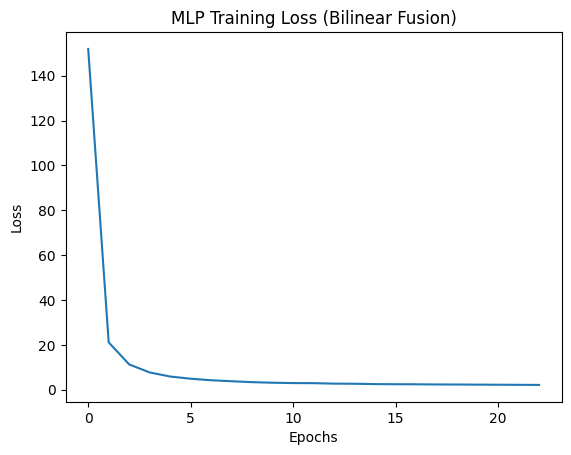

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import copy
import matplotlib.pyplot as plt

# 1. Ensure tensors are on the correct device
S = S.to(device)
S_given = S_given.to(device)
train_idx = torch.tensor(train_idx).to(device)
valid_idx = torch.tensor(valid_idx).to(device)
test_idx  = torch.tensor(test_idx).to(device)
labels_tensor = torch.tensor(labels_tensor).to(device) 

# 2. Extract splits independently (NO concatenation)
# Treat S as structural (str) and S_given as semantic (sem)
str_train = S[train_idx].detach()
str_valid = S[valid_idx].detach()
str_test  = S[test_idx].detach()

sem_train = S_given[train_idx].detach()
sem_valid = S_given[valid_idx].detach()
sem_test  = S_given[test_idx].detach()

y_train = labels_tensor[train_idx].long()
y_valid = labels_tensor[valid_idx].long()
y_test  = labels_tensor[test_idx].long()

# Free up original tensors if memory is tight
del S, S_given

print(f"Train nodes: {str_train.shape[0]} | Valid nodes: {str_valid.shape[0]} | Test nodes: {str_test.shape[0]}")

# 3. Independent Standardization
# Standardize Structural (S)
mean_str = str_train.mean(dim=0, keepdim=True)
std_str  = str_train.std(dim=0, keepdim=True) + 1e-7
str_train_scaled = (str_train - mean_str) / std_str
str_valid_scaled = (str_valid - mean_str) / std_str
str_test_scaled  = (str_test - mean_str) / std_str

# Standardize Semantic (S_given)
mean_sem = sem_train.mean(dim=0, keepdim=True)
std_sem  = sem_train.std(dim=0, keepdim=True) + 1e-7
sem_train_scaled = (sem_train - mean_sem) / std_sem
sem_valid_scaled = (sem_valid - mean_sem) / std_sem
sem_test_scaled  = (sem_test - mean_sem) / std_sem

# 4. DataLoader (Taking both sets of features)
batch_size = 2048
train_dataset = TensorDataset(str_train_scaled, sem_train_scaled, y_train)
train_loader  = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# 5. Define the Parameterized Bilinear Fusion Network
class BilinearFusionMLP(nn.Module):
    def __init__(self, str_dim, sem_dim, latent_dim, hidden, out_dim):
        super().__init__()
        
        # Encode into shared latent space
        self.proj_str = nn.Linear(str_dim, latent_dim)
        self.proj_sem = nn.Linear(sem_dim, latent_dim)
        self.relu = nn.ReLU()
        
        # True Learnable Bilinear Matrix
        # self.bilinear = nn.Bilinear(latent_dim, latent_dim, latent_dim)
        
        # Downstream Classifier directly over the encoded space :
        self.net = nn.Sequential(
            nn.Linear(latent_dim*2, hidden), 
            nn.ReLU(),
            nn.Dropout(0.5), 
            nn.Linear(hidden, hidden), 
            nn.ReLU(),
            nn.Dropout(0.5), 
            nn.Linear(hidden, out_dim)
        )

    def forward(self, x_str, x_sem):
        h_str = self.relu(self.proj_str(x_str))
        h_sem = self.relu(self.proj_sem(x_sem))
        h_fused = self.relu(torch.cat((h_str, h_sem), dim = 1))
        return self.net(h_fused)

# Initialize Model
str_dim = str_train.shape[1]
sem_dim = sem_train.shape[1]
latent_dim = 64
# Ensure num_classes is defined globally in your script
model = BilinearFusionMLP(str_dim, sem_dim, latent_dim, 64, num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
# Added Scheduler from your reference
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

epochs = 200
losses = []
best_val_acc = 0.0
best_model_weights = None
patience = 20  
epochs_no_improve = 0
target_threshold = 0.99 

for epoch in range(epochs):
    
    # --- TRAINING PHASE ---
    model.train()
    epoch_loss = 0.0
    
    for batch_str, batch_sem, batch_y in train_loader:
        optimizer.zero_grad()
        logits = model(batch_str, batch_sem)
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        
    avg_train_loss = epoch_loss / len(train_loader)
    losses.append(epoch_loss)
    
    # --- VALIDATION PHASE ---
    model.eval()
    with torch.no_grad():
        # Using full-batch evaluation since it fits in GPU
        train_logits = model(str_train_scaled, sem_train_scaled)
        train_preds = train_logits.argmax(dim=1)
        train_acc = (train_preds == y_train).float().mean().item()
        
        val_logits = model(str_valid_scaled, sem_valid_scaled)
        val_preds = val_logits.argmax(dim=1)
        val_correct = (val_preds == y_valid).sum().item()
        val_acc = val_correct / len(y_valid)

    # Step the scheduler safely AFTER validation
    scheduler.step(val_acc)

    print(f'Epoch {epoch+1:3d}/{epochs} | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}')

    # --- EARLY STOPPING LOGIC ---
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_weights = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    # Condition 1: Hit target threshold
    if val_acc >= target_threshold:
        print(f"\nTarget Validation Accuracy ({target_threshold}) reached! Stopping early.")
        break
        
    # Condition 2: Ran out of patience
    if epochs_no_improve >= patience:
        print(f"\nEarly stopping triggered! No improvement for {patience} epochs.")
        break

# 7. Final Test Evaluation using the Best Model
print(f"\nLoading best model weights (Val Acc: {best_val_acc:.4f}) for Final Testing...")
model.load_state_dict(best_model_weights)

# Free up memory
del str_train, str_valid, sem_train, sem_valid

# Use a dataloader for testing, passing BOTH test feature sets
test_loader = DataLoader(
    TensorDataset(str_test_scaled, sem_test_scaled, y_test),
    batch_size=4096,
    shuffle=False
)

model.eval()
all_preds = []

with torch.no_grad():
    for batch_str, batch_sem, _ in test_loader:
        batch_str = batch_str.to(device)
        batch_sem = batch_sem.to(device)
        logits = model(batch_str, batch_sem)
        preds = logits.argmax(dim=1)
        all_preds.append(preds.cpu())

test_preds = torch.cat(all_preds)
test_correct = (test_preds == y_test.cpu()).sum().item()
test_acc = test_correct / len(y_test)

print(f"Final Test Accuracy (Parameterized Bilinear Fusion): {test_acc:.4f}")

plt.plot(losses)
plt.title("MLP Training Loss (Bilinear Fusion)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

## CLIP based Contrastive Alignment :

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import copy
import wandb # Imported wandb
from torch.utils.data import DataLoader, TensorDataset

# ==========================================================
# 1. Dual Projection Architecture (Encoding the Space)
# ==========================================================
class ContrastiveProjectionHead(nn.Module):
    def __init__(self, input_dim=100, hidden_dim=256, latent_dim=128):
        super().__init__()
        self.proj_str = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim)
        )
        self.proj_sem = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim)
        )
        
        self.logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))

    def forward(self, x_str, x_sem):
        z_str = self.proj_str(x_str)
        z_sem = self.proj_sem(x_sem)

        z_str = F.normalize(z_str, p=2, dim=-1)
        z_sem = F.normalize(z_sem, p=2, dim=-1)

        return z_str, z_sem

# ==========================================================
# 2. The InfoNCE Loss Function
# ==========================================================
def symmetric_infonce_loss(z_str, z_sem, logit_scale):
    logits_per_str = logit_scale.exp() * torch.matmul(z_str, z_sem.t())
    logits_per_sem = logits_per_str.t() 

    batch_size = z_str.shape[0]
    labels = torch.arange(batch_size, dtype=torch.long, device=z_str.device)

    loss_str = F.cross_entropy(logits_per_str, labels)
    loss_sem = F.cross_entropy(logits_per_sem, labels)

    return (loss_str + loss_sem) / 2

# ==========================================================
# 3. Data Scaling & Preparation
# ==========================================================
S = S.to(device)
S_given = S_given.to(device)

print("\n--- Standardizing Tensors ---")
mean_S = S.mean(dim=0, keepdim=True)
std_S = S.std(dim=0, keepdim=True) + 1e-7
S_scaled = (S - mean_S) / std_S

mean_S_given = S_given.mean(dim=0, keepdim=True)
std_S_given = S_given.std(dim=0, keepdim=True) + 1e-7
S_given_scaled = (S_given - mean_S_given) / std_S_given

batch_size = 4096 
dataset = TensorDataset(S_scaled, S_given_scaled) 
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

# ==========================================================
# 4. Execution & Training Loop
# ==========================================================
# Hyperparameters for easy tracking
config = {
    "input_dim": 100,
    "hidden_dim": 512,
    "latent_dim": 128,
    "batch_size": batch_size,
    "learning_rate": 0.005,
    "weight_decay": 1e-4,
    "epochs": 1000,
    "patience": 10
}

# Initialize W&B
wandb.init(
    project="fuse-ogbn-products-contrastive",
    name="latent-alignment-infonce",
    config=config
)

model = ContrastiveProjectionHead(
    input_dim=config["input_dim"], 
    hidden_dim=config["hidden_dim"], 
    latent_dim=config["latent_dim"]
).to(device)

optimizer = optim.Adam(model.parameters(), lr=config["learning_rate"], weight_decay=config["weight_decay"])
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.9)

print("\n--- Starting Contrastive Latent Alignment ---")

best_loss = float('inf')
epochs_no_improve = 0
best_model_weights = copy.deepcopy(model.state_dict())

for epoch in range(config["epochs"]):
    model.train()
    total_loss = 0.0
    
    # Analytical Trackers
    total_top1_acc = 0.0
    total_pos_sim = 0.0
    total_neg_sim = 0.0
    
    for batch_str, batch_sem in loader:
        optimizer.zero_grad()
        
        z_str, z_sem = model(batch_str, batch_sem)
        loss = symmetric_infonce_loss(z_str, z_sem, model.logit_scale)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        # ---------------------------------------------------------
        # ANALYTICAL TRACKING (No Gradients Needed)
        # ---------------------------------------------------------
        with torch.no_grad():
            raw_sim = torch.matmul(z_str, z_sem.t())
            curr_batch_size = raw_sim.shape[0]
            labels = torch.arange(curr_batch_size, device=raw_sim.device)
            
            preds = raw_sim.argmax(dim=1)
            acc = (preds == labels).float().mean().item()
            total_top1_acc += acc
            
            pos_sim = torch.diag(raw_sim).mean().item()
            total_pos_sim += pos_sim
            
            sum_all = raw_sim.sum().item()
            sum_pos = torch.diag(raw_sim).sum().item()
            neg_sim = (sum_all - sum_pos) / (curr_batch_size * (curr_batch_size - 1))
            total_neg_sim += neg_sim
            
    # Calculate Epoch Averages
    num_batches = len(loader)
    avg_loss = total_loss / num_batches
    avg_top1 = total_top1_acc / num_batches
    avg_pos = total_pos_sim / num_batches
    avg_neg = total_neg_sim / num_batches
    
    current_temp = model.logit_scale.exp().item()
    
    scheduler.step()

    # Log to W&B
    wandb.log({
        "epoch": epoch + 1,
        "InfoNCE_Loss": avg_loss,
        "Top1_Accuracy_Pct": avg_top1 * 100,
        "Pos_Similarity": avg_pos,
        "Neg_Similarity": avg_neg,
        "Temp_Scale": current_temp,
        "Learning_Rate": optimizer.param_groups[0]['lr']
    })

    # Early Stopping Logic 
    if avg_loss < best_loss - 1e-3:
        best_loss = avg_loss
        epochs_no_improve = 0
        best_model_weights = copy.deepcopy(model.state_dict())
    else:
        epochs_no_improve += 1

    # Print Analytical Report
    if (epoch + 1) % 1 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{config['epochs']} | Loss: {avg_loss:.4f} | "
              f"Top-1 Acc: {avg_top1*100:.1f}% | "
              f"Pos Sim: {avg_pos:.3f} | Neg Sim: {avg_neg:.3f} | "
              f"Temp: {current_temp:.1f}")



    if epoch == 50:
        break
    if epochs_no_improve >= config["patience"]:
        print(f"\nEarly stopping triggered! No improvement in loss for {config['patience']} epochs.")
        break

print("Contrastive Alignment Complete.")

# ==========================================================
# 5. Extracting the Fused Embeddings
# ==========================================================
print(f"\nLoading best model weights (Loss: {best_loss:.4f}) for extraction...")
model.load_state_dict(best_model_weights)
model.eval()

final_dataset = TensorDataset(S_scaled, S_given_scaled)
final_loader = DataLoader(final_dataset, batch_size=4096, shuffle=False)

all_z_str = []
all_z_sem = []

with torch.no_grad():
    for batch_str, batch_sem in final_loader:
        batch_z_str, batch_z_sem = model(batch_str, batch_sem)

        all_z_str.append(batch_z_str.cpu())
        all_z_sem.append(batch_z_sem.cpu())

Final_Z_str = torch.cat(all_z_str, dim=0)
Final_Z_sem = torch.cat(all_z_sem, dim=0)

Z_fused = Final_Z_str + Final_Z_sem

print(f"Final Fused Embedding Matrix Shape: {Z_fused.shape}")

# Finish W&B run
wandb.finish()


--- Standardizing Tensors ---


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

  ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: mehul22 (mehul22-iiser-thiruvananthapuram) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin



--- Starting Contrastive Latent Alignment ---
Epoch   1/1000 | Loss: 6.5343 | Top-1 Acc: 2.4% | Pos Sim: 0.496 | Neg Sim: 0.263 | Temp: 19.7
Epoch   2/1000 | Loss: 6.1920 | Top-1 Acc: 3.8% | Pos Sim: 0.448 | Neg Sim: 0.235 | Temp: 21.9
Epoch   3/1000 | Loss: 6.0992 | Top-1 Acc: 4.4% | Pos Sim: 0.416 | Neg Sim: 0.213 | Temp: 23.7
Epoch   4/1000 | Loss: 6.0522 | Top-1 Acc: 4.7% | Pos Sim: 0.396 | Neg Sim: 0.199 | Temp: 24.5
Epoch   5/1000 | Loss: 6.0209 | Top-1 Acc: 5.0% | Pos Sim: 0.384 | Neg Sim: 0.190 | Temp: 24.9
Epoch   9/1000 | Loss: 5.9621 | Top-1 Acc: 5.4% | Pos Sim: 0.364 | Neg Sim: 0.174 | Temp: 25.7
Epoch  10/1000 | Loss: 5.9573 | Top-1 Acc: 5.4% | Pos Sim: 0.362 | Neg Sim: 0.172 | Temp: 25.6
Epoch  11/1000 | Loss: 5.9520 | Top-1 Acc: 5.5% | Pos Sim: 0.361 | Neg Sim: 0.171 | Temp: 25.6
Epoch  12/1000 | Loss: 5.9476 | Top-1 Acc: 5.5% | Pos Sim: 0.360 | Neg Sim: 0.169 | Temp: 25.8
Epoch  13/1000 | Loss: 5.9446 | Top-1 Acc: 5.6% | Pos Sim: 0.359 | Neg Sim: 0.169 | Temp: 25.9
Epo

InfoNCE_Loss,█▄▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Learning_Rate,████████████████▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▁▁▁▁▁▁▁▁▁
Neg_Similarity,█▆▅▄▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Pos_Similarity,█▆▄▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Temp_Scale,▁▃▅▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇█▇██▇▇▇▇█▇█████████
Top1_Accuracy_Pct,▁▄▅▆▆▇▇▇▇▇▇▇▇▇▇▇▇███████████████████████
epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
InfoNCE_Loss,5.88784
Learning_Rate,0.00405
Neg_Similarity,0.15945
Pos_Similarity,0.34585


In [9]:

torch.save(Z_fused, "Clip_Products.pth")


In [10]:
import json
import os

dataset_metadata = {
    "title": "ogbn-products-CLIP-fused",
    "id": "mehulgoyal1729/ogbn-products-CLIP-fused",
    "licenses": [{"name": "CC0-1.0"}]
}




with open("/kaggle/working/dataset-metadata.json", "w") as f:
    json.dump(dataset_metadata, f)

In [11]:

!kaggle datasets create -p /kaggle/working

Skipping folder: wandb; use '--dir-mode' to upload folders
Skipping folder: .virtual_documents; use '--dir-mode' to upload folders
Starting upload for file Clip_Products.pth
100%|███████████████████████████████████████| 1.17G/1.17G [00:11<00:00, 109MB/s]
Upload successful: Clip_Products.pth (1GB)
Your private Dataset is being created. Please check progress at https://www.kaggle.com/datasets/mehulgoyal1729/ogbn-products-CLIP-fused


In [12]:
clip_fused = torch.load(r"/kaggle/input/datasets/mehulgoyal1729/ogbn-products-clip-fused/Clip_Products.pth")

In [13]:
clip_fused.shape

torch.Size([2449029, 128])

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import copy
from torch.utils.data import TensorDataset, DataLoader

S_generated = clip_fused

print(f"Shape of concatenated embeddings: {S_generated.shape}")

train_idx = torch.tensor(train_idx).to(device)
valid_idx = torch.tensor(valid_idx).to(device)
test_idx  = torch.tensor(test_idx).to(device)
labels_tensor = torch.tensor(labels_tensor).to(device)
S_generated = S_generated.to(device)



print(S_generated.device)
print(train_idx.device)

S_train = S_generated[train_idx].detach()
y_train = labels_tensor[train_idx].long()

S_valid = S_generated[valid_idx].detach()
y_valid = labels_tensor[valid_idx].long()

S_test = S_generated[test_idx].detach()
y_test = labels_tensor[test_idx].long()

del S_generated

print(
    f"Train nodes: {S_train.shape[0]} | "
    f"Valid nodes: {S_valid.shape[0]} | "
    f"Test nodes: {S_test.shape[0]}"
)

mean = S_train.mean(dim=0, keepdim=True)
std = S_train.std(dim=0, keepdim=True) + 1e-7

S_train_scaled = (S_train - mean) / std
S_valid_scaled = (S_valid - mean) / std
S_test_scaled  = (S_test - mean) / std

batch_size = 2048

train_dataset = TensorDataset(S_train_scaled, y_train)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

class MLP(nn.Module):
    def __init__(self, in_dim, hidden, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.BatchNorm1d(hidden),   
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(hidden, hidden),
            nn.BatchNorm1d(hidden),  
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(hidden, out_dim)
        )

    def forward(self, x):
        return self.net(x)

K = S_train.shape[1]

model = MLP(K, 512, num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay = 1e-5)

epochs = 200
best_val_acc = 0
best_model_weights = None

patience = 20
epochs_no_improve = 0
target_threshold = 0.99

for epoch in range(epochs):

    #########################
    # TRAINING
    #########################

    model.train()

    epoch_loss = 0

    for batch_x, batch_y in train_loader:

        optimizer.zero_grad()

        logits = model(batch_x)

        loss = criterion(logits, batch_y)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_train_loss = epoch_loss / len(train_loader)

    #########################
    # ACCURACY EVALUATION
    #########################

    model.eval()

    with torch.no_grad():

        # ---- Train accuracy ----
        train_logits = model(S_train_scaled)
        train_preds = train_logits.argmax(dim=1)

        train_correct = (
            train_preds == y_train
        ).sum().item()

        train_acc = train_correct / len(y_train)

        # ---- Validation accuracy ----
        val_logits = model(S_valid_scaled)

        val_preds = val_logits.argmax(dim=1)

        val_correct = (
            val_preds == y_valid
        ).sum().item()

        val_acc = val_correct / len(y_valid)

    gap = train_acc - val_acc

    print(
        f"Epoch {epoch+1:3d}/{epochs} | "
        f"Loss: {avg_train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Gap: {gap:.4f}"
    )

    #########################
    # EARLY STOPPING
    #########################

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_weights = copy.deepcopy(
            model.state_dict()
        )
        epochs_no_improve = 0

    else:
        epochs_no_improve += 1

    if val_acc >= target_threshold:
        print(
            f"\nTarget validation accuracy "
            f"{target_threshold} reached."
        )
        break

    if epochs_no_improve >= patience:
        print(
            f"\nEarly stopping "
            f"(no improvement for {patience} epochs)"
        )
        break


####################################
# TEST EVALUATION
####################################

print(
    f"\nLoading best model "
    f"(Val Acc={best_val_acc:.4f})"
)

model.load_state_dict(best_model_weights)

test_loader = DataLoader(
    TensorDataset(S_test_scaled, y_test),
    batch_size=4096,
    shuffle=False
)

model.eval()

all_preds = []

with torch.no_grad():

    for batch_x, _ in test_loader:

        logits = model(batch_x)

        preds = logits.argmax(dim=1)

        all_preds.append(
            preds.cpu()
        )

test_preds = torch.cat(all_preds)

test_acc = (
    (test_preds == y_test.cpu())
    .sum()
    .item()
    / len(y_test)
)

print(f"Final Test Accuracy: {test_acc:.4f}")

Shape of concatenated embeddings: torch.Size([2449029, 128])


/tmp/ipykernel_57/3735061999.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_idx = torch.tensor(train_idx).to(device)
/tmp/ipykernel_57/3735061999.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  valid_idx = torch.tensor(valid_idx).to(device)
/tmp/ipykernel_57/3735061999.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_idx  = torch.tensor(test_idx).to(device)
/tmp/ipykernel_57/3735061999.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detac

cuda:0
cuda:0
Train nodes: 196615 | Valid nodes: 39323 | Test nodes: 2213091
Epoch   1/200 | Loss: 0.2878 | Train Acc: 0.9979 | Val Acc: 0.8180 | Gap: 0.1799
Epoch   2/200 | Loss: 0.0191 | Train Acc: 0.9990 | Val Acc: 0.8185 | Gap: 0.1805
Epoch   3/200 | Loss: 0.0099 | Train Acc: 0.9992 | Val Acc: 0.8133 | Gap: 0.1860
Epoch   4/200 | Loss: 0.0067 | Train Acc: 0.9995 | Val Acc: 0.8122 | Gap: 0.1873
Epoch   5/200 | Loss: 0.0049 | Train Acc: 0.9997 | Val Acc: 0.8056 | Gap: 0.1942
Epoch   6/200 | Loss: 0.0034 | Train Acc: 0.9998 | Val Acc: 0.8067 | Gap: 0.1932
Epoch   7/200 | Loss: 0.0025 | Train Acc: 0.9999 | Val Acc: 0.8032 | Gap: 0.1966
Epoch   8/200 | Loss: 0.0020 | Train Acc: 0.9999 | Val Acc: 0.7929 | Gap: 0.2070
Epoch   9/200 | Loss: 0.0017 | Train Acc: 0.9999 | Val Acc: 0.8002 | Gap: 0.1997
Epoch  10/200 | Loss: 0.0014 | Train Acc: 0.9999 | Val Acc: 0.7975 | Gap: 0.2024
Epoch  11/200 | Loss: 0.0026 | Train Acc: 0.9999 | Val Acc: 0.8067 | Gap: 0.1933
Epoch  12/200 | Loss: 0.0028 | T

In [15]:
S_generated = clip_fused

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score



train_idx = torch.tensor(train_idx).to(device)
valid_idx =  torch.tensor(valid_idx).to(device)
test_idx  =  torch.tensor(test_idx).to(device)
labels_tensor = torch.tensor(labels_tensor).to(device) 

S_generated = S_generated.to(device)

S_train = S_generated[train_idx].detach()
y_train = labels_tensor[train_idx].long()

S_valid = S_generated[valid_idx].detach()
y_valid = labels_tensor[valid_idx].long()

S_test  = S_generated[test_idx].detach()
y_test  = labels_tensor[test_idx].long()



print("\n--- Transferring Data to CPU for Scikit-Learn ---")
X_train_np = S_train.cpu().numpy()
y_train_np = y_train.cpu().numpy()

X_test_np  = S_test.cpu().numpy()
y_test_np  = y_test.cpu().numpy()

print("Training Logistic Regression...")
clf = LogisticRegression(max_iter=1000, multi_class='multinomial', n_jobs=-1)
clf.fit(X_train_np, y_train_np)

print("Evaluating on Test Set...")
y_pred = clf.predict(X_test_np)


print(f"Accuracy: {accuracy_score(y_pred,y_test_np )}")


print("\n--- Logistic Regression Classification Report ---")
print(classification_report(y_test_np, y_pred, digits=4))

/tmp/ipykernel_57/3732168673.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_idx = torch.tensor(train_idx).to(device)
/tmp/ipykernel_57/3732168673.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  valid_idx =  torch.tensor(valid_idx).to(device)
/tmp/ipykernel_57/3732168673.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_idx  =  torch.tensor(test_idx).to(device)
/tmp/ipykernel_57/3732168673.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach(


--- Transferring Data to CPU for Scikit-Learn ---
Training Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Evaluating on Test Set...
Accuracy: 0.7632804073578537

--- Logistic Regression Classification Report ---


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0     0.6772    0.7951    0.7314    100670
           1     0.6954    0.7543    0.7237     95236
           2     0.8932    0.8344    0.8628    102870
           3     0.7560    0.6189    0.6806    135255
           4     0.9289    0.8800    0.9038    596195
           5     0.6635    0.8536    0.7466     35985
           6     0.7338    0.7904    0.7611    140356
           7     0.7758    0.9588    0.8577    152202
           8     0.7841    0.9614    0.8638     97679
           9     0.8736    0.8919    0.8826     59852
          10     0.6468    0.8230    0.7243     47165
          11     0.3140    0.4978    0.3851     28933
          12     0.8487    0.6206    0.7170    128632
          13     0.7508    0.7800    0.7651     88694
          14     0.3449    0.4682    0.3972      2734
          15     0.6962    0.9353    0.7982     23871
          16     0.6737    0.6600    0.6668     83019
          17     0.8497    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
